In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('svm_new_data_predictions_28.csv')

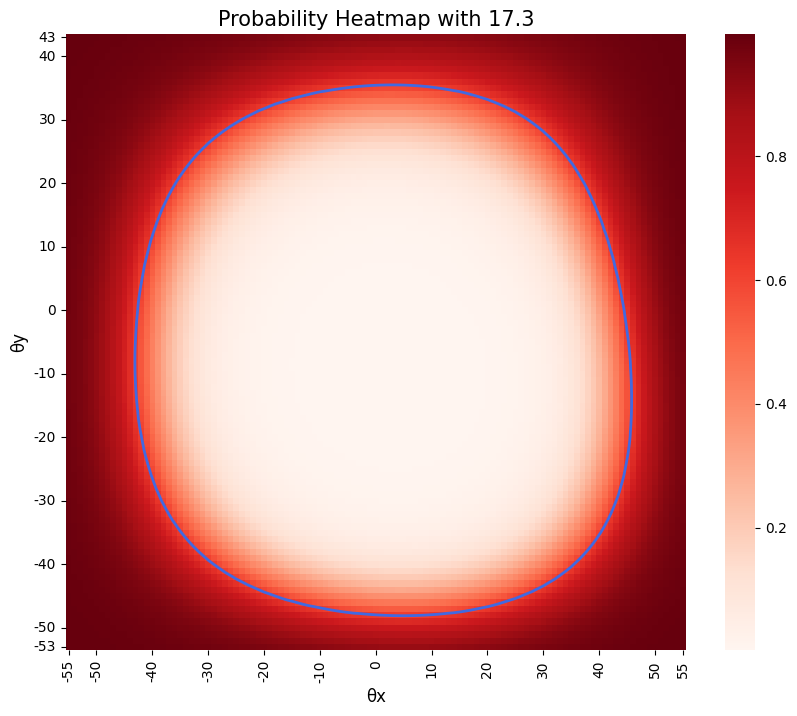

In [ ]:
# 2. 히트맵을 위한 데이터 재구조화 (Pivot)
# Yaw를 가로축(Columns), Pitch를 세로축(Index)으로 설정
heatmap_data = df.pivot(index='Pitch', columns='Yaw', values='Probability')

# 컨투어(등고선)를 그리기 위한 좌표값 준비
X = heatmap_data.columns.values
Y = heatmap_data.index.values
Z = heatmap_data.values

# 3. 그래프 그리기 (단일 컬러 + 검정 등고선 버전)
plt.figure(figsize=(10, 8))

sns.heatmap(heatmap_data, cmap='Reds')

yaw_ticks = [-55, -50, -40, -30,-20 ,-10, 0 ,10, 20, 30, 40, 50, 55]
pitch_ticks = [-53, -50, -40, -30,-20 ,-10, 0 ,10, 20, 30, 40, 43]
x_indices = [np.argmin(np.abs(heatmap_data.columns.values - val)) + 0.5 for val in yaw_ticks]
y_indices = [np.argmin(np.abs(heatmap_data.index.values - val)) + 0.5 for val in pitch_ticks]

plt.xticks(x_indices, yaw_ticks)
plt.yticks(y_indices, pitch_ticks)
# 등고선(Contour) 추가
# np.arange... + 0.5 는 히트맵 셀의 중앙에 선을 맞추기 위한 보정입니다.
plt.contour(np.arange(len(X)) + 0.5, 
            np.arange(len(Y)) + 0.5, 
            Z, 
            levels=[0.5433169615],
            colors='royalblue', 
            linewidths=2)

# 그래프 설정
plt.title('Probability Heatmap with 28.3', fontsize=15)
plt.xlabel('θx', fontsize=12)
plt.ylabel('θy', fontsize=12)

# 세로축 방향 뒤집기 (일반적인 Pitch 좌표계 대응)
plt.gca().invert_yaxis()

# 이미지 저장 및 출력
plt.savefig('my_probability_heatmap.png', dpi=300)
plt.show()